In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

dataset = r'data/processed/'
nomes_mun = pd.read_csv('municipio_tse_ibge.csv', sep=';', encoding='latin1')
dados = []
arquivos_processados = 0
total_contingencias = 0

for raiz, pastas, arquivos in os.walk(dataset):
    for nome in arquivos:
        if nome.endswith('logd.dat'):
            caminho_completo = os.path.join(raiz, nome)
                      
            municipio = None
            zona = None
            secao = None
            tdvpe = []
            inicio_voto = None
            urna_contingencia = "Não"
            timeout_biometria = 0
            tecla_indevida = 0
            inatividade = 0
            sem_biometria = 0
            titulo_invalido = 0
            
            tdvpe_por_turno = {
               "1º Turno": {"antes_17": [], "depois_17": []}, 
               "2º Turno": {"antes_17": [], "depois_17": []}          
            }
            huv_por_turno = {"1º Turno": None, "2º Turno": None}
            turno_atual = "1º Turno"
         
            with open(caminho_completo, 'r', encoding='latin1', errors='replace') as arquivo_log:
                    for linha in arquivo_log:
                        texto_busca = linha.lower()
                       
                        if "urna de contingência" in texto_busca:
                           urna_contingencia = "Sim" 
                        if "iniciando aplicação" in texto_busca and "turno" in texto_busca:
                         if "1º turno" in texto_busca:
                            turno_atual = "1º Turno"
                         elif "2º turno" in texto_busca:
                            turno_atual = "2º Turno"

                        if "município" in texto_busca and municipio is None:
                           municipio = texto_busca.split("município")[1].replace(":", "").split()[0]
                        elif "zona eleitoral" in texto_busca and zona is None:
                           zona = texto_busca.split("zona eleitoral")[1].replace(":", "").split()[0]
                        elif "seção eleitoral" in texto_busca:
                            secao_nova = texto_busca.split("seção eleitoral")[1].replace(":", "").split()[0]
                          # Só atualiza se ainda não tem seção OU se a seção atual é "0000"
                          # (urna de contingência começa com 0000 e depois recebe a seção real)
                            if secao is None or secao in ('0', '00', '000', '0000'):
                              secao = secao_nova
                 
                        elif "eleitor foi habilitado" in texto_busca:
                            tempo_texto = linha[0:19]
                            inicio_voto = datetime.strptime(tempo_texto, "%d/%m/%Y %H:%M:%S")

                    
                        elif "o voto do eleitor foi computado" in texto_busca:
                            if inicio_voto is not None:
                                tempo_texto = linha[0:19]
                                fim_voto = datetime.strptime(tempo_texto, "%d/%m/%Y %H:%M:%S")
                                voto = (fim_voto - inicio_voto).total_seconds()
                                if fim_voto.hour < 17:
                                    tdvpe_por_turno[turno_atual]["antes_17"].append(voto)
                                else:
                                    tdvpe_por_turno[turno_atual]["depois_17"].append(voto)
                               
                                huv_por_turno[turno_atual] = fim_voto.strftime("%H:%M:%S")
                                inicio_voto = None
                        if "timeout de reconhecimento do dedo" in texto_busca and turno_atual == "1º Turno":
                           timeout_biometria += 1
                        if "o eleitor não possui biometria" in texto_busca and turno_atual == "1º Turno":
                             sem_biometria += 1
                        if "tecla indevida pressionada" in texto_busca and turno_atual == "1º Turno":
                             tecla_indevida += 1
                        if "eleitor sem atividade por " in texto_busca and turno_atual == "1º Turno":
                            inatividade += 1
                        if "título inválido" in texto_busca and turno_atual == "1º Turno":
                             titulo_invalido += 1
           
            for turno, cestas in tdvpe_por_turno.items():
               votos_antes = cestas["antes_17"]
               votos_depois = cestas["depois_17"]
               if len(votos_antes) > 0 or len(votos_depois) > 0:
                                    
                    delta_antes = round(np.mean(votos_antes), 2) if len(votos_antes) > 0 else 0.0
                    desvio_antes = round(np.std(votos_antes), 2) if len(votos_antes) > 1 else 0.0
                    
                    delta_depois = round(np.mean(votos_depois), 2) if len(votos_depois) > 0 else 0.0
                    desvio_depois = round(np.std(votos_depois), 2) if len(votos_depois) > 1 else 0.0 
                    if urna_contingencia == "Sim" and turno == "1º Turno":
                        total_contingencias += 1              
                    dados.append({
                          'NM_MUNICIPIO': municipio,
                          'NR_ZONA': zona,
                          'NR_SECAO': secao,
                          'TURNO': turno,
                          'CONTINGENCIA': urna_contingencia, 
                          'QT_ELEITORES': len(tdvpe),
                          'QT_ELEITORES_ANTES_17': len(votos_antes),
                          'DELTA_T_ANTES_17': delta_antes,
                          'DESVIO_ANTES_17': desvio_antes,
                          'QT_ELEITORES_DEPOIS_17': len(votos_depois),
                          'DELTA_T_DEPOIS_17': delta_depois,
                          'DESVIO_DEPOIS_17': desvio_depois,
                          'ULTIMO_VOTO': huv_por_turno[turno],
                          'TIMEOUT_BIOMETRIA': timeout_biometria,
                          'TECLA_INDEVIDA': tecla_indevida,
                          'INATIVIDADE': inatividade,
                          'SEM_BIOMETRIA': sem_biometria,
                          'TITULO_INVALIDO': titulo_invalido,
                      })     
            arquivos_processados += 1

            
df_csv = pd.DataFrame(dados)
nome_arquivo_csv = 'df_csv.csv'
df_csv.to_csv(nome_arquivo_csv, index=False, sep=';', encoding='utf-8-sig')

municipios_se = nomes_mun[nomes_mun['SG_UF'] == 'SE'].copy()
municipios_se['CD_MUNICIPIO_TSE'] = municipios_se['CD_MUNICIPIO_TSE'].astype(str)
df_csv['NM_MUNICIPIO'] = df_csv['NM_MUNICIPIO'].astype(str)

df_csv = df_csv.merge(municipios_se[['CD_MUNICIPIO_TSE', 'NM_MUNICIPIO_TSE']], 
                      left_on='NM_MUNICIPIO', 
                      right_on='CD_MUNICIPIO_TSE', 
                      how='left',)
                      
df_csv = df_csv.drop(columns=['NM_MUNICIPIO', 'CD_MUNICIPIO_TSE'], errors='ignore')
df_csv = df_csv.rename(columns={'NM_MUNICIPIO_TSE': 'NM_MUNICIPIO'})
colunas = ['NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO', 'TURNO', 'CONTINGENCIA',
    'QT_ELEITORES_ANTES_17', 'DELTA_T_ANTES_17', 'DESVIO_ANTES_17',
    'QT_ELEITORES_DEPOIS_17', 'DELTA_T_DEPOIS_17', 'DESVIO_DEPOIS_17', 
    'ULTIMO_VOTO', 'TIMEOUT_BIOMETRIA', 'TECLA_INDEVIDA', 'INATIVIDADE', 'SEM_BIOMETRIA','TITULO_INVALIDO']
df_csv = df_csv[colunas]


print(f"total de arquivos/urnas abertos e verificados:", {arquivos_processados})
print(f" Total de urnas com votos válidos na tabela: {len(df_csv)/2}")
print(f" Urnas de contingência 1 turno (Substituídas): {total_contingencias}")
display(df_csv.head())

total de arquivos/urnas abertos e verificados: {5498}
 Total de urnas com votos válidos na tabela: 5366.0
 Urnas de contingência 1 turno (Substituídas): 203


,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO,CONTINGENCIA,QT_ELEITORES_ANTES_17,DELTA_T_ANTES_17,DESVIO_ANTES_17,QT_ELEITORES_DEPOIS_17,DELTA_T_DEPOIS_17,DESVIO_DEPOIS_17,ULTIMO_VOTO,TIMEOUT_BIOMETRIA,TECLA_INDEVIDA,INATIVIDADE,SEM_BIOMETRIA,TITULO_INVALIDO
0,Frei Paulo,0024,0117,1º Turno,Não,283,61.47,32.90,48,51.21,15.10,18:05:58,13,462,5,23,10
1,Frei Paulo,0024,0117,2º Turno,Não,322,20.92,10.65,0,0.00,0.00,16:55:07,13,462,5,23,10
2,Japaratuba,0011,0090,1º Turno,Não,248,84.64,59.58,28,54.50,19.24,17:43:13,38,617,12,6,17
3,Japaratuba,0011,0090,2º Turno,Não,284,24.43,21.04,0,0.00,0.00,16:40:45,38,617,12,6,17
4,Brejo Grande,0015,0082,1º Turno,Sim,38,86.89,43.67,0,0.00,0.00,16:55:23,2,85,0,0,0


In [2]:
df_csv['TEMP_HORA'] = pd.to_datetime(df_csv['ULTIMO_VOTO'], format='%H:%M:%S', errors='coerce')
minutos_totais = (df_csv['TEMP_HORA'].dt.hour * 60) + df_csv['TEMP_HORA'].dt.minute

df_csv['ATRASO_FILA_MINUTOS'] = minutos_totais - (17 * 60) 
df_csv.loc[df_csv['ATRASO_FILA_MINUTOS'] < 0, 'ATRASO_FILA_MINUTOS'] = 0 
df_csv = df_csv.drop(columns=['TEMP_HORA'])
display(df_csv.head())

,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO,CONTINGENCIA,QT_ELEITORES_ANTES_17,DELTA_T_ANTES_17,DESVIO_ANTES_17,QT_ELEITORES_DEPOIS_17,DELTA_T_DEPOIS_17,DESVIO_DEPOIS_17,ULTIMO_VOTO,TIMEOUT_BIOMETRIA,TECLA_INDEVIDA,INATIVIDADE,SEM_BIOMETRIA,TITULO_INVALIDO,ATRASO_FILA_MINUTOS
0,Frei Paulo,0024,0117,1º Turno,Não,283,61.47,32.90,48,51.21,15.10,18:05:58,13,462,5,23,10,65
1,Frei Paulo,0024,0117,2º Turno,Não,322,20.92,10.65,0,0.00,0.00,16:55:07,13,462,5,23,10,0
2,Japaratuba,0011,0090,1º Turno,Não,248,84.64,59.58,28,54.50,19.24,17:43:13,38,617,12,6,17,43
3,Japaratuba,0011,0090,2º Turno,Não,284,24.43,21.04,0,0.00,0.00,16:40:45,38,617,12,6,17,0
4,Brejo Grande,0015,0082,1º Turno,Sim,38,86.89,43.67,0,0.00,0.00,16:55:23,2,85,0,0,0,0


1º Turno: 1665 seções atrasaram. Média de atraso: 33.4 minutos.
2º Turno: 50 seções atrasaram. Média de atraso: 2.7 minutos.


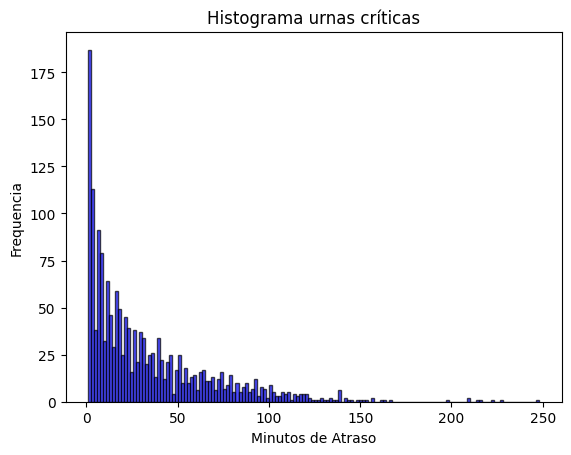

In [3]:
df_atraso_1t = df_csv.query("TURNO == '1º Turno' and ATRASO_FILA_MINUTOS > 0 and CONTINGENCIA == 'Não'")
df_atraso_2t = df_csv.query("TURNO == '2º Turno' and ATRASO_FILA_MINUTOS > 0 and CONTINGENCIA == 'Não'")

media_atraso_1t = df_atraso_1t['ATRASO_FILA_MINUTOS'].mean()
media_atraso_2t = df_atraso_2t['ATRASO_FILA_MINUTOS'].mean()

print(f"1º Turno: {len(df_atraso_1t)} seções atrasaram. Média de atraso: {media_atraso_1t:.1f} minutos.")
print(f"2º Turno: {len(df_atraso_2t)} seções atrasaram. Média de atraso: {media_atraso_2t:.1f} minutos.")

plt.hist(df_atraso_1t['ATRASO_FILA_MINUTOS'], bins=150, color='blue', edgecolor='black', alpha=0.7)
plt.title('Histograma urnas críticas')
plt.xlabel('Minutos de Atraso')
plt.ylabel('Frequencia')
plt.show() 

In [37]:
from scipy.stats import poisson

def poisson_mixture_em(data, k=3, max_iter=1000, tol=1e-6, fixed_pi=False):
    """
    Algoritmo EM para separar dados em 'k' grupos usando uma Mistura de Poisson.
    
    Parâmetros:
    - data: array de dados (ex: minutos de atraso).
    - k: número de componentes/grupos (padrão=3).
    - max_iter: número máximo de iterações.
    - tol: tolerância para convergência.
    - fixed_pi: se True, força a probabilidade de cada grupo a ser 1/k (ex: 1/3).
    """
    # Converter para numpy array caso seja uma série do pandas
    data = np.asarray(data)
    n = len(data)
    
    # 1. Inicialização
    # Escolhemos valores iniciais para os lambdas baseados nos percentis dos dados
    percentis = np.linspace(10, 90, k)
    lambdas = np.percentile(data, percentis)
    
    # Probabilidades iniciais de cada grupo (ex: 1/3, 1/3, 1/3)
    pis = np.ones(k) / k
    
    responsibilities = np.zeros((n, k))
    log_likelihoods = []
    
    for iteration in range(max_iter):
        # Calcular a probabilidade (responsabilidade) de cada ponto pertencer a cada grupo
        for j in range(k):
            responsibilities[:, j] = pis[j] * poisson.pmf(data, lambdas[j])
        
        # Soma das probabilidades para cada ponto
        resp_sum = responsibilities.sum(axis=1)
        
        # Calcular a log-verossimilhança total para checar a convergência
        log_likelihood = np.sum(np.log(resp_sum + 1e-10))
        log_likelihoods.append(log_likelihood)
        
        if iteration > 0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
            break
            
        # Normalizar as responsabilidades para que a soma por linha seja 1
        responsibilities = responsibilities / resp_sum[:, np.newaxis]
        
        # Calcular o número esperado de pontos em cada grupo
        Nk = responsibilities.sum(axis=0)
        
        # Atualizar as taxas médias (lambdas) de cada grupo Poisson
        lambdas = np.sum(responsibilities * data[:, np.newaxis], axis=0) / Nk
        
        # Atualizar as probabilidades da mistura (pis), a menos que estejam fixas em 1/3
        if not fixed_pi:
            pis = Nk / n
            
    # Classificar cada ponto no grupo com a maior probabilidade (responsabilidade)
    labels = np.argmax(responsibilities, axis=1)
    
    # Ordenar os grupos para que Grupo 0 tenha o menor atraso, e Grupo 2 o maior
    sort_idx = np.argsort(lambdas)
    lambdas_ordenados = lambdas[sort_idx]
    pis_ordenados = pis[sort_idx]
    
    # Reatribuir as labels de acordo com a ordem correta
    label_map = {old_label: new_label for new_label, old_label in enumerate(sort_idx)}
    labels_ordenadas = np.array([label_map[l] for l in labels])
    
    return lambdas_ordenados, pis_ordenados, labels_ordenadas

dados_atraso = df_atraso_1t.loc[df_atraso_1t['ATRASO_FILA_MINUTOS'] > 0, 'ATRASO_FILA_MINUTOS'].values

lambdas_otimos, pesos_otimos, classes = poisson_mixture_em(dados_atraso, k=3, fixed_pi=True)

print("=== RESULTADOS DO ALGORITMO EM ===")
for i in range(3):
    print(f"Grupo {i+1}: Lambda (Média) = {lambdas_otimos[i]:.2f} min | Probabilidade = {pesos_otimos[i]:.2%}")

=== RESULTADOS DO ALGORITMO EM ===
Grupo 1: Lambda (Média) = 6.48 min | Probabilidade = 33.33%
Grupo 2: Lambda (Média) = 32.15 min | Probabilidade = 33.33%
Grupo 3: Lambda (Média) = 89.36 min | Probabilidade = 33.33%


In [40]:
g1 = 6.48
g2 = 32.15
g3 = 89.36
g4 = 150

condicoes_1t = [
    (df_atraso_1t['ATRASO_FILA_MINUTOS'] >= g1) & (df_atraso_1t['ATRASO_FILA_MINUTOS'] < g2),
    (df_atraso_1t['ATRASO_FILA_MINUTOS'] >= g2) & (df_atraso_1t['ATRASO_FILA_MINUTOS'] < g3), 
    (df_atraso_1t['ATRASO_FILA_MINUTOS'] >= g3) & (df_atraso_1t['ATRASO_FILA_MINUTOS'] < g4),
    (df_atraso_1t['ATRASO_FILA_MINUTOS'] > g4)
]
rotulos_1t = ['1', '2', '3', '4']

df_atraso_1t['STATUS'] = np.select(condicoes_1t, rotulos_1t, default='0')

print(df_atraso_1t['STATUS'].value_counts())
df_atraso_1t.to_csv('df_atraso_2022.csv', index=False, sep=';', encoding='utf-8-sig')

STATUS
1    656
2    490
0    387
3    117
4     15
Name: count, dtype: int64


In [17]:
print("TODAS AS URNAS CRÍTICAS - 1º TURNO ")
# Filtra apenas as críticas e ordena do maior para o menor atraso, mostrando tudo
display(
    df_atraso_1t[df_atraso_1t['STATUS'] == '3']
    .sort_values(by='ATRASO_FILA_MINUTOS', ascending=False)
)

TODAS AS URNAS CRÍTICAS - 1º TURNO 


,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO,CONTINGENCIA,QT_ELEITORES_ANTES_17,DELTA_T_ANTES_17,DESVIO_ANTES_17,QT_ELEITORES_DEPOIS_17,DELTA_T_DEPOIS_17,DESVIO_DEPOIS_17,ULTIMO_VOTO,TIMEOUT_BIOMETRIA,TECLA_INDEVIDA,INATIVIDADE,SEM_BIOMETRIA,TITULO_INVALIDO,ATRASO_FILA_MINUTOS,STATUS
522,Lagarto,0012,0129,1º Turno,Não,213,84.33,64.64,51,76.51,53.26,18:46:50,34,850,17,0,11,106,3
8928,Nossa Senhora Do Socorro,0034,0133,1º Turno,Não,257,63.77,42.30,64,51.17,21.54,18:46:00,4,658,9,12,33,106,3
84,Estância,0006,0187,1º Turno,Não,216,72.12,40.17,52,63.52,26.40,18:45:40,22,744,7,5,10,105,3
8286,Aracaju,0027,0167,1º Turno,Não,273,67.49,44.56,62,57.13,30.12,18:44:22,4,1001,6,2,16,104,3
5054,Gararu,0008,0043,1º Turno,Não,248,81.35,57.93,60,64.10,23.65,18:44:27,0,910,15,18,22,104,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5232,Nossa Senhora Do Socorro,0034,0326,1º Turno,Não,333,52.29,30.53,41,45.49,14.59,17:53:07,3,576,4,123,17,53,3
1769,Tobias Barreto,0023,0095,1º Turno,Não,186,104.36,80.98,30,70.97,40.60,17:53:39,0,660,14,12,2,53,3
7920,Porto Da Folha,0018,0046,1º Turno,Não,266,89.48,63.66,26,95.42,61.58,17:53:24,0,737,19,15,9,53,3
441,Lagarto,0012,0004,1º Turno,Não,195,80.14,93.79,26,59.88,34.17,17:53:52,25,632,14,29,10,53,3


/tmp/ipykernel_5811/1068398474.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(


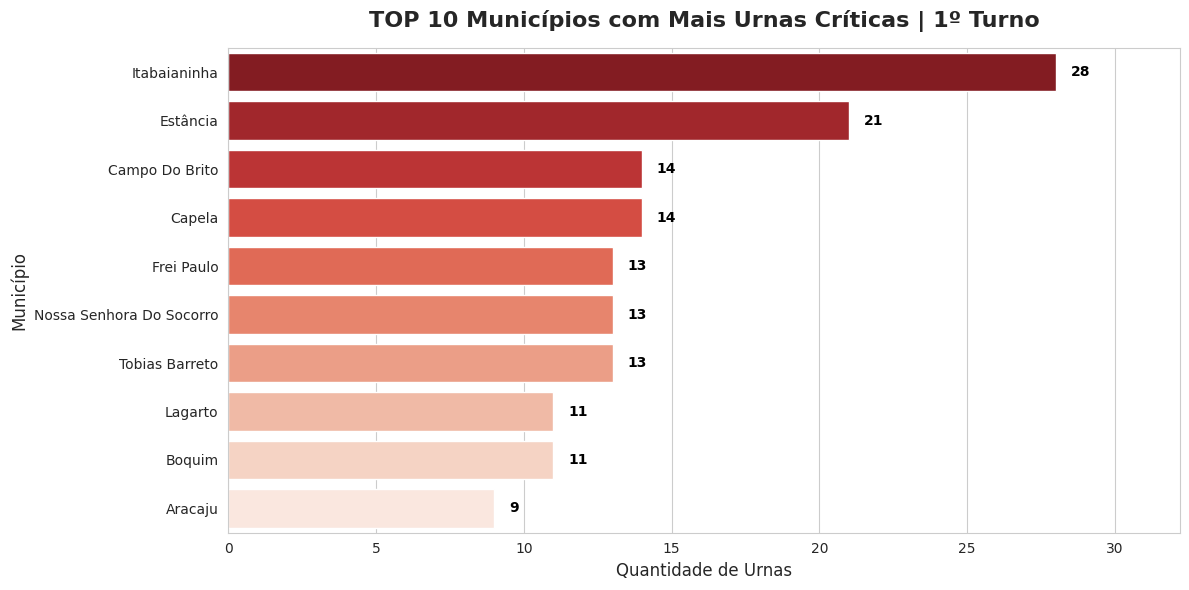

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparando os dados: Pegar apenas as urnas críticas do 1º turno
criticas_1t = df_atraso_1t[df_atraso_1t['STATUS'] == '3']

# 2. Contando quantas urnas críticas cada município teve e pegando o Top 10
top10_cidades = criticas_1t['NM_MUNICIPIO'].value_counts().head(10).reset_index()
top10_cidades.columns = ['Município', 'Qtd_Urnas_Criticas']

# 3. Configurando a beleza do gráfico
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid") # Fundo limpo

# 4. Desenhando o gráfico de barras horizontais
grafico = sns.barplot(
    x='Qtd_Urnas_Criticas', 
    y='Município', 
    data=top10_cidades, 
    palette='Reds_r' # Paleta de cores vermelhas (reforçando a ideia de alerta)
)

# 5. Adicionando os números na ponta de cada barra
for index, value in enumerate(top10_cidades['Qtd_Urnas_Criticas']):
    grafico.text(value + 0.5, index, str(value), color='black', va='center', fontweight='bold')

# 6. Títulos e eixos
plt.title('TOP 10 Municípios com Mais Urnas Críticas | 1º Turno', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Quantidade de Urnas', fontsize=12)
plt.ylabel('Município', fontsize=12)
plt.xlim(0, top10_cidades['Qtd_Urnas_Criticas'].max() * 1.15) # Dá um espaço extra para o texto caber

# Exibindo o gráfico final
plt.tight_layout()
plt.show()
criticas_1t.to_csv('secoes_criticas_2022.csv', index=False, sep=';', encoding='utf-8-sig')

STATUS
0     7.383333
1    11.345216
2    15.130243
3    20.124590
4    28.608108
Name: TIMEOUT_BIOMETRIA, dtype: float64


/tmp/ipykernel_5811/235421432.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(x=media_timeout_biometria.values,
/tmp/ipykernel_5811/235421432.py:8: UserWarning: 
The palette list has fewer values (3) than needed (5) and will cycle, which may produce an uninterpretable plot.
  grafico = sns.barplot(x=media_timeout_biometria.values,


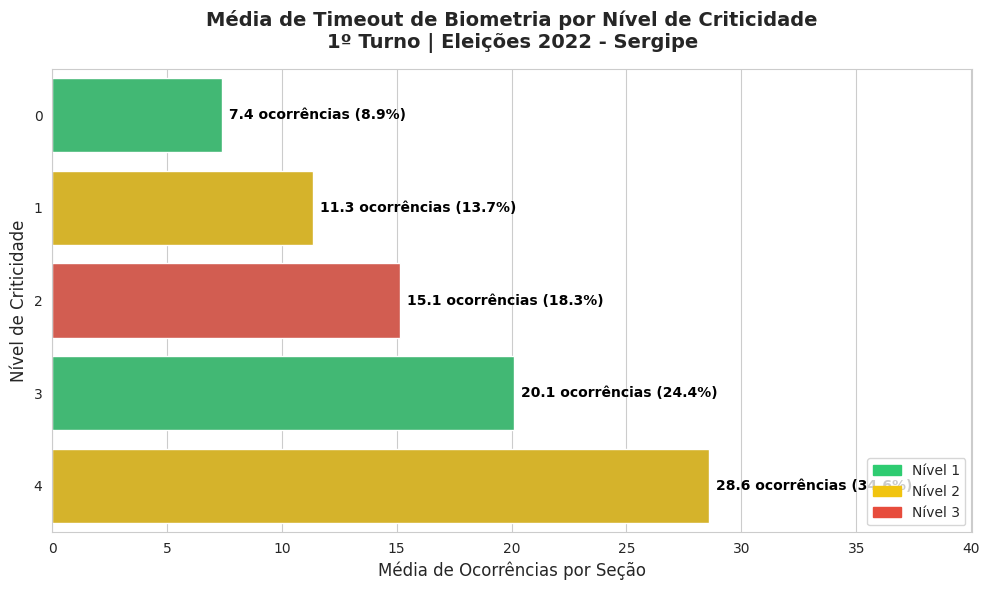

In [19]:
media_timeout_biometria = df_atraso_1t.groupby('STATUS')['TIMEOUT_BIOMETRIA'].mean()
print(media_timeout_biometria)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

cores = ['#2ecc71', '#f1c40f', '#e74c3c']
grafico = sns.barplot(x=media_timeout_biometria.values, 
                      y=media_timeout_biometria.index.astype(str), 
                      palette=cores)

for index, value in enumerate(media_timeout_biometria.values):
    pct = (value / media_timeout_biometria.sum() * 100).round(1)
    grafico.text(value + 0.3, index, f'{value:.1f} ocorrências ({pct}%)', 
                 color='black', va='center', fontweight='bold', fontsize=10)

plt.title('Média de Timeout de Biometria por Nível de Criticidade\n1º Turno | Eleições 2022 - Sergipe', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Média de Ocorrências por Seção', fontsize=12)
plt.ylabel('Nível de Criticidade', fontsize=12)
plt.xlim(0, media_timeout_biometria.max() * 1.4)

labels = ['Nível 1', 'Nível 2', 'Nível 3']
handles = [plt.Rectangle((0,0),1,1, color=c) for c in cores]
plt.legend(handles, labels, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

STATUS
0    492.263333
1    544.930582
2    601.726269
3    658.104918
4    733.216216
Name: TECLA_INDEVIDA, dtype: float64


/tmp/ipykernel_5811/1335672460.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(x=media_tecla_indevida.values,
/tmp/ipykernel_5811/1335672460.py:8: UserWarning: 
The palette list has fewer values (3) than needed (5) and will cycle, which may produce an uninterpretable plot.
  grafico = sns.barplot(x=media_tecla_indevida.values,


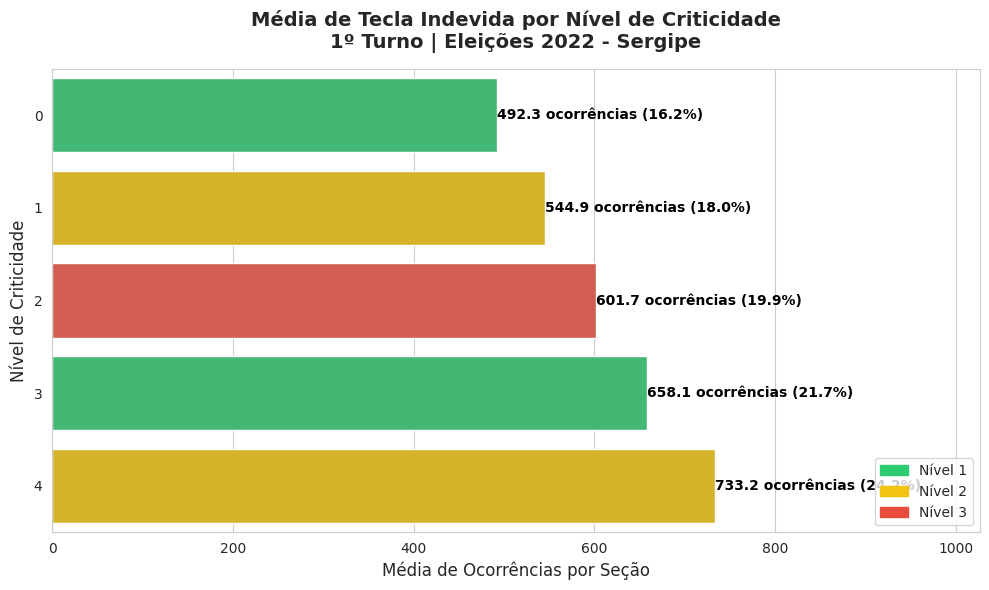

In [20]:
media_tecla_indevida = df_atraso_1t.groupby('STATUS')['TECLA_INDEVIDA'].mean()
print(media_tecla_indevida)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

cores = ['#2ecc71', '#f1c40f', '#e74c3c']
grafico = sns.barplot(x=media_tecla_indevida.values, 
                      y=media_tecla_indevida.index.astype(str), 
                      palette=cores)

for index, value in enumerate(media_tecla_indevida.values):
    pct = (value / media_tecla_indevida.sum() * 100).round(1)
    grafico.text(value + 0.3, index, f'{value:.1f} ocorrências ({pct}%)', 
                 color='black', va='center', fontweight='bold', fontsize=10)

plt.title('Média de Tecla Indevida por Nível de Criticidade\n1º Turno | Eleições 2022 - Sergipe', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Média de Ocorrências por Seção', fontsize=12)
plt.ylabel('Nível de Criticidade', fontsize=12)
plt.xlim(0, media_tecla_indevida.max() * 1.4)

labels = ['Nível 1', 'Nível 2', 'Nível 3']
handles = [plt.Rectangle((0,0),1,1, color=c) for c in cores]
plt.legend(handles, labels, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

STATUS
0     9.486667
1    10.403377
2    11.366446
3    13.108197
4    17.905405
Name: INATIVIDADE, dtype: float64


/tmp/ipykernel_5811/2066727588.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(x=media_inatividade.values,
/tmp/ipykernel_5811/2066727588.py:8: UserWarning: 
The palette list has fewer values (3) than needed (5) and will cycle, which may produce an uninterpretable plot.
  grafico = sns.barplot(x=media_inatividade.values,


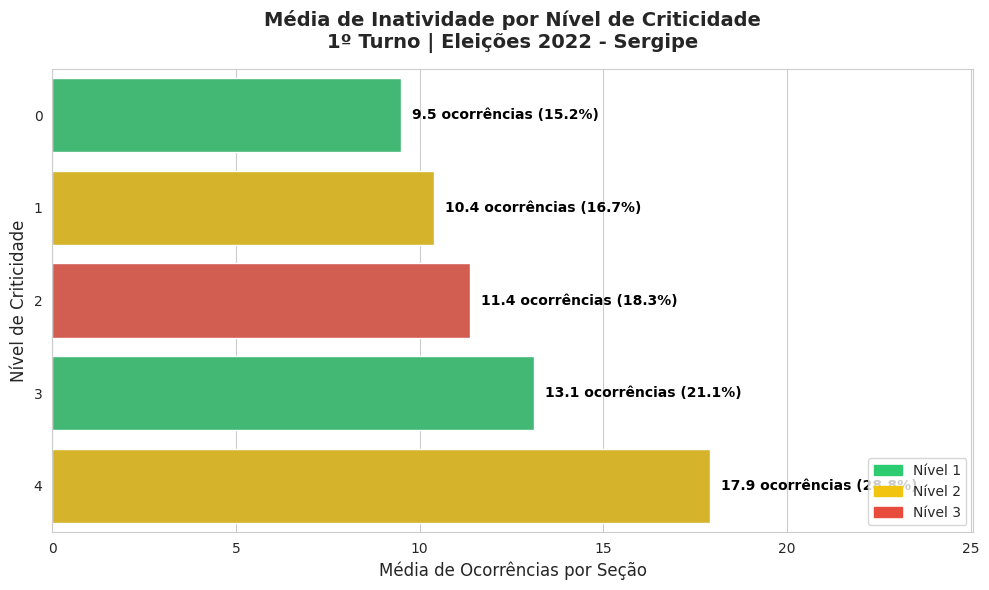

In [21]:
media_inatividade = df_atraso_1t.groupby('STATUS')['INATIVIDADE'].mean()
print(media_inatividade)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

cores = ['#2ecc71', '#f1c40f', '#e74c3c']
grafico = sns.barplot(x=media_inatividade.values, 
                      y=media_inatividade.index.astype(str), 
                      palette=cores)

for index, value in enumerate(media_inatividade.values):
    pct = (value / media_inatividade.sum() * 100).round(1)
    grafico.text(value + 0.3, index, f'{value:.1f} ocorrências ({pct}%)', 
                 color='black', va='center', fontweight='bold', fontsize=10)

plt.title('Média de Inatividade por Nível de Criticidade\n1º Turno | Eleições 2022 - Sergipe', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Média de Ocorrências por Seção', fontsize=12)
plt.ylabel('Nível de Criticidade', fontsize=12)
plt.xlim(0, media_inatividade.max() * 1.4)

labels = ['Nível 1', 'Nível 2', 'Nível 3']
handles = [plt.Rectangle((0,0),1,1, color=c) for c in cores]
plt.legend(handles, labels, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

STATUS
0    16.076667
1    14.724203
2    13.415011
3    13.596721
4    15.986486
Name: SEM_BIOMETRIA, dtype: float64


/tmp/ipykernel_5811/1953403469.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(x=media_sem_biometria.values,
/tmp/ipykernel_5811/1953403469.py:8: UserWarning: 
The palette list has fewer values (3) than needed (5) and will cycle, which may produce an uninterpretable plot.
  grafico = sns.barplot(x=media_sem_biometria.values,


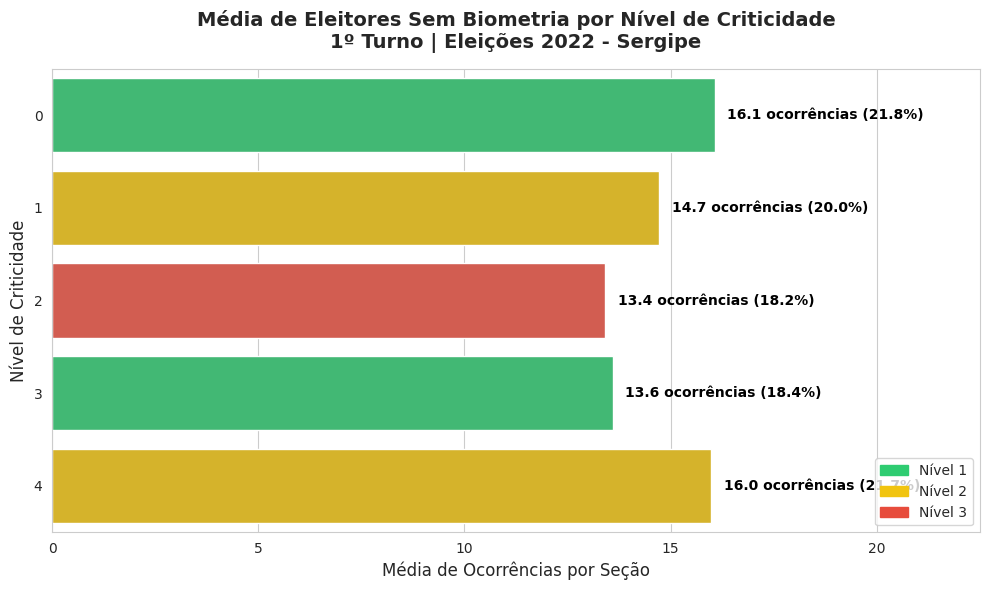

In [22]:
media_sem_biometria = df_atraso_1t.groupby('STATUS')['SEM_BIOMETRIA'].mean()
print(media_sem_biometria)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

cores = ['#2ecc71', '#f1c40f', '#e74c3c']
grafico = sns.barplot(x=media_sem_biometria.values, 
                      y=media_sem_biometria.index.astype(str), 
                      palette=cores)

for index, value in enumerate(media_sem_biometria.values):
    pct = (value / media_sem_biometria.sum() * 100).round(1)
    grafico.text(value + 0.3, index, f'{value:.1f} ocorrências ({pct}%)', 
                 color='black', va='center', fontweight='bold', fontsize=10)

plt.title('Média de Eleitores Sem Biometria por Nível de Criticidade\n1º Turno | Eleições 2022 - Sergipe', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Média de Ocorrências por Seção', fontsize=12)
plt.ylabel('Nível de Criticidade', fontsize=12)
plt.xlim(0, media_sem_biometria.max() * 1.4)

labels = ['Nível 1', 'Nível 2', 'Nível 3']
handles = [plt.Rectangle((0,0),1,1, color=c) for c in cores]
plt.legend(handles, labels, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

STATUS
0    12.043333
1    12.534709
2    13.143488
3    13.268852
4    13.972973
Name: TITULO_INVALIDO, dtype: float64


/tmp/ipykernel_5811/1586917309.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(x=media_titulo_invalido.values,
/tmp/ipykernel_5811/1586917309.py:8: UserWarning: 
The palette list has fewer values (3) than needed (5) and will cycle, which may produce an uninterpretable plot.
  grafico = sns.barplot(x=media_titulo_invalido.values,


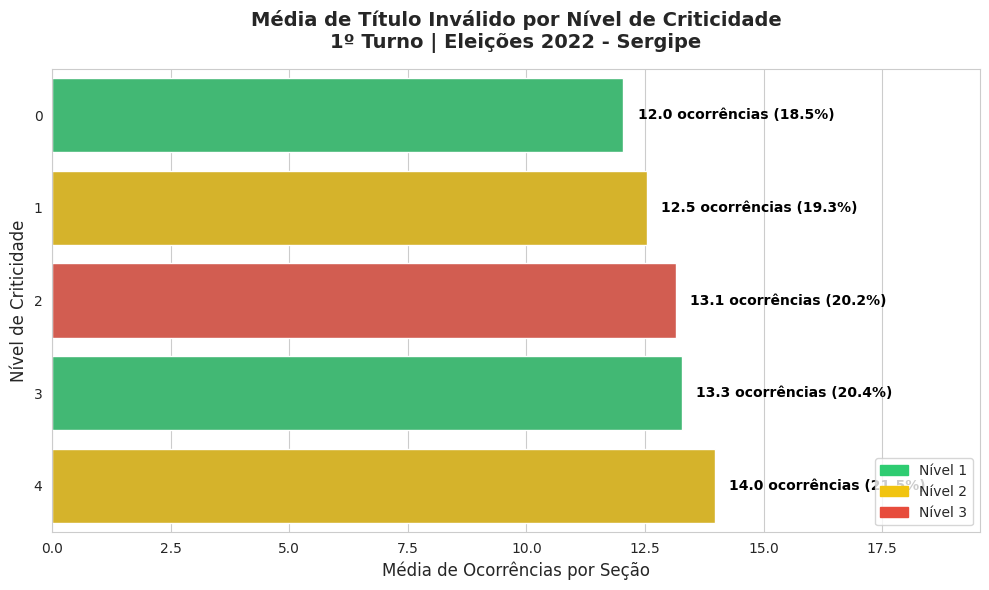

In [23]:
media_titulo_invalido = df_atraso_1t.groupby('STATUS')['TITULO_INVALIDO'].mean()
print(media_titulo_invalido)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

cores = ['#2ecc71', '#f1c40f', '#e74c3c']
grafico = sns.barplot(x=media_titulo_invalido.values, 
                      y=media_titulo_invalido.index.astype(str), 
                      palette=cores)

for index, value in enumerate(media_titulo_invalido.values):
    pct = (value / media_titulo_invalido.sum() * 100).round(1)
    grafico.text(value + 0.3, index, f'{value:.1f} ocorrências ({pct}%)', 
                 color='black', va='center', fontweight='bold', fontsize=10)

plt.title('Média de Título Inválido por Nível de Criticidade\n1º Turno | Eleições 2022 - Sergipe', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Média de Ocorrências por Seção', fontsize=12)
plt.ylabel('Nível de Criticidade', fontsize=12)
plt.xlim(0, media_titulo_invalido.max() * 1.4)

labels = ['Nível 1', 'Nível 2', 'Nível 3']
handles = [plt.Rectangle((0,0),1,1, color=c) for c in cores]
plt.legend(handles, labels, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

In [24]:
nivel3_2018 = pd.read_csv('secoes_criticas_2018.csv', sep=';', encoding='utf-8-sig')
criticas_2022 = pd.read_csv('df_atraso_2022.csv', sep=';', encoding='utf-8-sig')

df_perfil = pd.read_csv('perfil_eleitor_secao_2022_SE.csv', sep=';', encoding='latin1')

df_perfil['NM_MUNICIPIO'] = df_perfil['NM_MUNICIPIO'].str.upper()
criticas_2022['NM_MUNICIPIO'] = criticas_2022['NM_MUNICIPIO'].str.upper()
#df_perfil[df_perfil['NR_SECAO'] == 75].head(20)

In [25]:
criticas_2022 = criticas_2022.merge(
    df_perfil,
    on=['NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO'],
    how='inner'
)

df_perfil_n3 = criticas_2022.query("STATUS == 4")
df_perfil_n2 = criticas_2022.query("STATUS == 3")
df_perfil_n1 = criticas_2022.query("STATUS == 2")

display(df_perfil_n3)

,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO,CONTINGENCIA,QT_ELEITORES_ANTES_17,DELTA_T_ANTES_17,DESVIO_ANTES_17,QT_ELEITORES_DEPOIS_17,DELTA_T_DEPOIS_17,...,DS_IDENTIDADE_GENERO,CD_QUILOMBOLA,DS_QUILOMBOLA,CD_INTERPRETE_LIBRAS,DS_INTERPRETE_LIBRAS,TP_OBRIGATORIEDADE_VOTO,QT_ELEITORES_PERFIL,QT_ELEITORES_BIOMETRIA,QT_ELEITORES_DEFICIENCIA,QT_ELEITORES_INC_NM_SOCIAL
5166,FREI PAULO,24,103,1º Turno,Não,247,63.61,37.01,85,48.21,...,#NE,-3,#NE,-3,#NE,Obrigatório,2,2,0,0
5167,FREI PAULO,24,103,1º Turno,Não,247,63.61,37.01,85,48.21,...,#NE,-3,#NE,-3,#NE,Obrigatório,4,4,0,0
5168,FREI PAULO,24,103,1º Turno,Não,247,63.61,37.01,85,48.21,...,#NE,-3,#NE,-3,#NE,Facultativo,7,0,0,0
5169,FREI PAULO,24,103,1º Turno,Não,247,63.61,37.01,85,48.21,...,#NE,-3,#NE,-3,#NE,Obrigatório,1,0,0,0
5170,FREI PAULO,24,103,1º Turno,Não,247,63.61,37.01,85,48.21,...,#NE,-3,#NE,-3,#NE,Obrigatório,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239053,ESTÂNCIA,6,113,1º Turno,Não,232,85.52,46.62,81,69.53,...,#NE,-3,#NE,-3,#NE,Obrigatório,2,2,0,0
239054,ESTÂNCIA,6,113,1º Turno,Não,232,85.52,46.62,81,69.53,...,#NE,-3,#NE,-3,#NE,Obrigatório,3,3,0,0
239055,ESTÂNCIA,6,113,1º Turno,Não,232,85.52,46.62,81,69.53,...,#NE,-3,#NE,-3,#NE,Obrigatório,10,10,0,0
239056,ESTÂNCIA,6,113,1º Turno,Não,232,85.52,46.62,81,69.53,...,#NE,-3,#NE,-3,#NE,Obrigatório,2,2,0,0


DS_FAIXA_ETARIA
100 anos ou mais                    11
16 anos                            160
17 anos                            240
18 anos                            349
19 anos                            379
20 anos                            353
21 a 24 anos                      1802
25 a 29 anos                      2439
30 a 34 anos                      2408
35 a 39 anos                      2527
40 a 44 anos                      2725
45 a 49 anos                      2310
50 a 54 anos                      1924
55 a 59 anos                      1835
60 a 64 anos                      1491
65 a 69 anos                      1167
70 a 74 anos                       908
75 a 79 anos                       658
80 a 84 anos                       399
85 a 89 anos                       181
90 a 94 anos                        80
95 a 99 anos                        26
Name: QT_ELEITORES_PERFIL, dtype: int64


/tmp/ipykernel_5811/3378508337.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(x=df_idade.values, y=df_idade.index, palette='Blues_r')


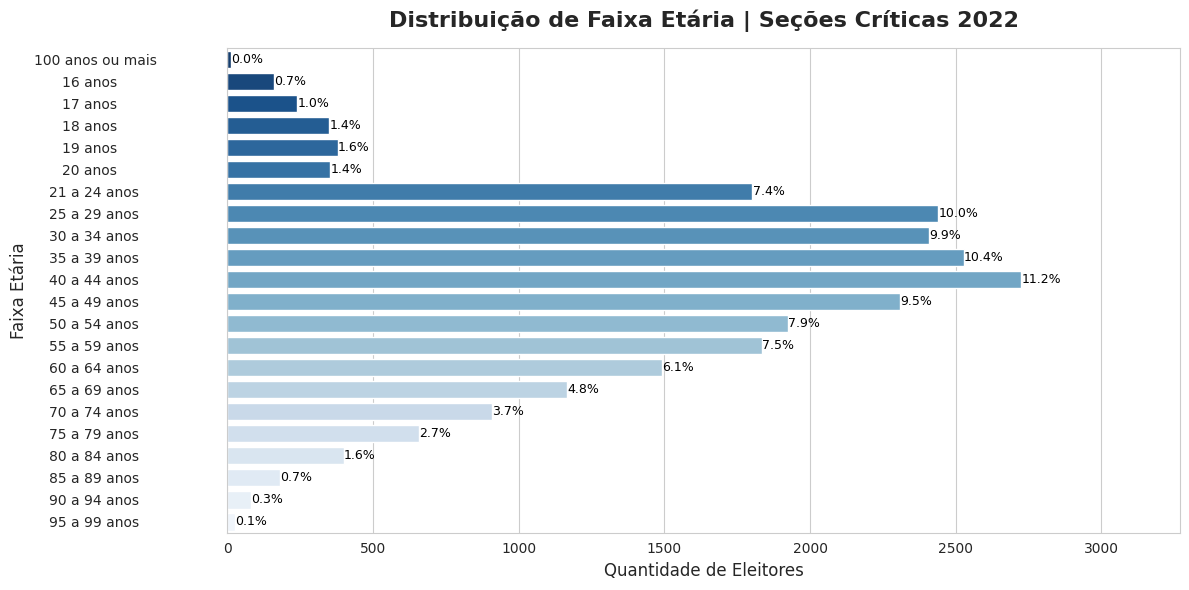

In [26]:
df_idade = df_perfil_n3.groupby('DS_FAIXA_ETARIA')['QT_ELEITORES_PERFIL'].sum()
print(df_idade)
plt.figure(figsize=(12, 6))
grafico = sns.barplot(x=df_idade.values, y=df_idade.index, palette='Blues_r')

# Adiciona o percentual na ponta de cada barra
total = df_idade.sum()
for index, value in enumerate(df_idade.values):
    pct = (value / total * 100).round(1)
    grafico.text(value + 1, index, f'{pct}%', color='black', va='center', fontsize=9)

plt.title('Distribuição de Faixa Etária | Seções Críticas 2022', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Quantidade de Eleitores', fontsize=12)
plt.ylabel('Faixa Etária', fontsize=12)
plt.xlim(0, df_idade.max() * 1.2)

plt.tight_layout()
plt.show()

DS_GRAU_ESCOLARIDADE
ANALFABETO                       2457
ENSINO FUNDAMENTAL COMPLETO       851
ENSINO FUNDAMENTAL INCOMPLETO    9212
ENSINO MÉDIO COMPLETO            2937
ENSINO MÉDIO INCOMPLETO          3299
LÊ E ESCREVE                     4735
SUPERIOR COMPLETO                 535
SUPERIOR INCOMPLETO               346
Name: QT_ELEITORES_PERFIL, dtype: int64


/tmp/ipykernel_5811/927795535.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(x=df_escolaridade.values, y=df_escolaridade.index, palette='Blues_r')


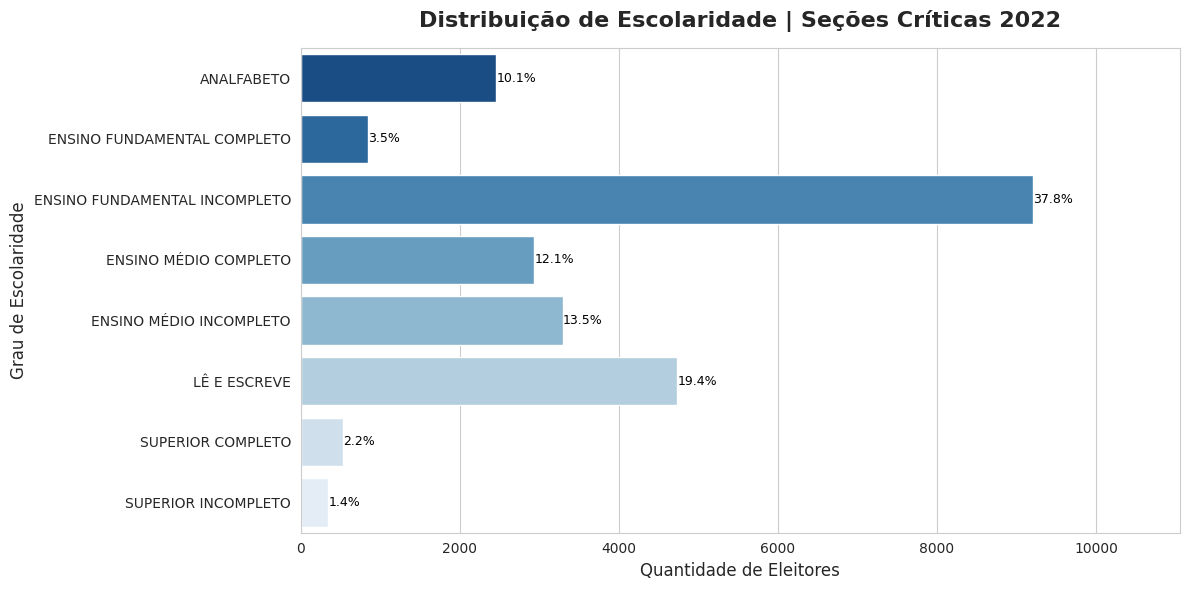

In [27]:
df_escolaridade = df_perfil_n3.groupby('DS_GRAU_ESCOLARIDADE')['QT_ELEITORES_PERFIL'].sum()
print(df_escolaridade)

plt.figure(figsize=(12, 6))
grafico = sns.barplot(x=df_escolaridade.values, y=df_escolaridade.index, palette='Blues_r')

# Adiciona o percentual na ponta de cada barra
total = df_escolaridade.sum()
for index, value in enumerate(df_escolaridade.values):
    pct = (value / total * 100).round(1)
    grafico.text(value + 1, index, f'{pct}%', color='black', va='center', fontsize=9)

plt.title('Distribuição de Escolaridade | Seções Críticas 2022', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Quantidade de Eleitores', fontsize=12)
plt.ylabel('Grau de Escolaridade', fontsize=12)
plt.xlim(0, df_escolaridade.max() * 1.2)

plt.tight_layout()
plt.show()

In [28]:
total_eleitores = df_perfil_n3['QT_ELEITORES_PERFIL'].sum()
pct_pcd = (10 / total_eleitores * 100).round(2)
print(f"Total de eleitores nas seções críticas: {total_eleitores}")
print(f"PCD representa: {pct_pcd}%")
total_biometria = df_perfil_n3['QT_ELEITORES_BIOMETRIA'].sum()
total_eleitores = df_perfil_n3['QT_ELEITORES_PERFIL'].sum()
pct_biometria = (total_biometria / total_eleitores * 100).round(2)
print(f"Total de eleitores com biometria: {total_biometria}")
print(f"Biometria representa: {pct_biometria}%")

Total de eleitores nas seções críticas: 24372
PCD representa: 0.04%
Total de eleitores com biometria: 23276
Biometria representa: 95.5%


In [29]:
nivel1 = df_atraso_1t[df_atraso_1t['STATUS'] == '1']
nivel2 = df_atraso_1t[df_atraso_1t['STATUS'] == '2']
df_perfil['NM_MUNICIPIO'] = df_perfil['NM_MUNICIPIO'].str.upper()
nivel2['NM_MUNICIPIO'] = nivel2['NM_MUNICIPIO'].str.upper()
nivel1['NM_MUNICIPIO'] = nivel1['NM_MUNICIPIO'].str.upper()
nivel1['NR_ZONA'] = nivel1['NR_ZONA'].astype(int)
nivel1['NR_SECAO'] = nivel1['NR_SECAO'].astype(int)
nivel2['NR_ZONA'] = nivel2['NR_ZONA'].astype(int)
nivel2['NR_SECAO'] = nivel2['NR_SECAO'].astype(int)

df_perfil_n2 = nivel2.merge(
    df_perfil,
    on=['NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO'],
    how='inner'
)

display(df_perfil_n2)

df_perfil_n1 = nivel1.merge(
    df_perfil,
    on=['NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO'],
    how='inner'
)

display(df_perfil_n1)

,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO,CONTINGENCIA,QT_ELEITORES_ANTES_17,DELTA_T_ANTES_17,DESVIO_ANTES_17,QT_ELEITORES_DEPOIS_17,DELTA_T_DEPOIS_17,...,DS_IDENTIDADE_GENERO,CD_QUILOMBOLA,DS_QUILOMBOLA,CD_INTERPRETE_LIBRAS,DS_INTERPRETE_LIBRAS,TP_OBRIGATORIEDADE_VOTO,QT_ELEITORES_PERFIL,QT_ELEITORES_BIOMETRIA,QT_ELEITORES_DEFICIENCIA,QT_ELEITORES_INC_NM_SOCIAL
0,JAPARATUBA,11,90,1º Turno,Não,248,84.64,59.58,28,54.50,...,#NE,-3,#NE,-3,#NE,Obrigatório,9,9,0,0
1,JAPARATUBA,11,90,1º Turno,Não,248,84.64,59.58,28,54.50,...,#NE,-3,#NE,-3,#NE,Obrigatório,1,1,0,0
2,JAPARATUBA,11,90,1º Turno,Não,248,84.64,59.58,28,54.50,...,#NE,-3,#NE,-3,#NE,Obrigatório,2,2,0,0
3,JAPARATUBA,11,90,1º Turno,Não,248,84.64,59.58,28,54.50,...,#NE,-3,#NE,-3,#NE,Obrigatório,6,6,0,0
4,JAPARATUBA,11,90,1º Turno,Não,248,84.64,59.58,28,54.50,...,#NE,-3,#NE,-3,#NE,Obrigatório,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66542,ARACAJU,27,277,1º Turno,Não,278,64.11,35.88,22,65.09,...,#NE,-3,#NE,-3,#NE,Obrigatório,1,1,0,0
66543,ARACAJU,27,277,1º Turno,Não,278,64.11,35.88,22,65.09,...,#NE,-3,#NE,-3,#NE,Obrigatório,13,13,0,0
66544,ARACAJU,27,277,1º Turno,Não,278,64.11,35.88,22,65.09,...,#NE,-3,#NE,-3,#NE,Obrigatório,4,4,0,0
66545,ARACAJU,27,277,1º Turno,Não,278,64.11,35.88,22,65.09,...,#NE,-3,#NE,-3,#NE,Facultativo,1,1,0,0


,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO,CONTINGENCIA,QT_ELEITORES_ANTES_17,DELTA_T_ANTES_17,DESVIO_ANTES_17,QT_ELEITORES_DEPOIS_17,DELTA_T_DEPOIS_17,...,DS_IDENTIDADE_GENERO,CD_QUILOMBOLA,DS_QUILOMBOLA,CD_INTERPRETE_LIBRAS,DS_INTERPRETE_LIBRAS,TP_OBRIGATORIEDADE_VOTO,QT_ELEITORES_PERFIL,QT_ELEITORES_BIOMETRIA,QT_ELEITORES_DEFICIENCIA,QT_ELEITORES_INC_NM_SOCIAL
0,SÃO CRISTÓVÃO,21,116,1º Turno,Não,281,65.05,40.47,2,237.00,...,#NE,-3,#NE,-3,#NE,Obrigatório,1,1,0,0
1,SÃO CRISTÓVÃO,21,116,1º Turno,Não,281,65.05,40.47,2,237.00,...,#NE,-3,#NE,-3,#NE,Facultativo,1,0,0,0
2,SÃO CRISTÓVÃO,21,116,1º Turno,Não,281,65.05,40.47,2,237.00,...,#NE,-3,#NE,-3,#NE,Obrigatório,1,1,0,0
3,SÃO CRISTÓVÃO,21,116,1º Turno,Não,281,65.05,40.47,2,237.00,...,#NE,-3,#NE,-3,#NE,Obrigatório,4,2,0,0
4,SÃO CRISTÓVÃO,21,116,1º Turno,Não,281,65.05,40.47,2,237.00,...,#NE,-3,#NE,-3,#NE,Obrigatório,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77539,NOSSA SENHORA DO SOCORRO,34,189,1º Turno,Não,279,67.32,40.14,7,59.14,...,#NE,-3,#NE,-3,#NE,Facultativo,1,1,0,0
77540,NOSSA SENHORA DO SOCORRO,34,189,1º Turno,Não,279,67.32,40.14,7,59.14,...,#NE,-3,#NE,-3,#NE,Facultativo,1,1,0,0
77541,NOSSA SENHORA DO SOCORRO,34,189,1º Turno,Não,279,67.32,40.14,7,59.14,...,#NE,-3,#NE,-3,#NE,Obrigatório,1,1,0,0
77542,NOSSA SENHORA DO SOCORRO,34,189,1º Turno,Não,279,67.32,40.14,7,59.14,...,#NE,-3,#NE,-3,#NE,Facultativo,1,1,0,0


DS_FAIXA_ETARIA
100 anos ou mais                     27
16 anos                             901
17 anos                            1484
18 anos                            2308
19 anos                            2753
20 anos                            2928
21 a 24 anos                      13373
25 a 29 anos                      20259
30 a 34 anos                      19865
35 a 39 anos                      19285
40 a 44 anos                      18684
45 a 49 anos                      15871
50 a 54 anos                      14114
55 a 59 anos                      12362
60 a 64 anos                       9416
65 a 69 anos                       6993
70 a 74 anos                       5173
75 a 79 anos                       3692
80 a 84 anos                       2027
85 a 89 anos                        849
90 a 94 anos                        318
95 a 99 anos                        110
Inválido                              1
Name: QT_ELEITORES_PERFIL, dtype: int64


/tmp/ipykernel_5811/2104972052.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_idade_n1.values, y=df_idade_n1.index, palette='Greens_r', ax=ax1)


DS_FAIXA_ETARIA
100 anos ou mais                     36
16 anos                             716
17 anos                            1100
18 anos                            1769
19 anos                            2248
20 anos                            2608
21 a 24 anos                      11880
25 a 29 anos                      16883
30 a 34 anos                      16000
35 a 39 anos                      17382
40 a 44 anos                      16766
45 a 49 anos                      14186
50 a 54 anos                      12581
55 a 59 anos                      10562
60 a 64 anos                       8144
65 a 69 anos                       6346
70 a 74 anos                       4708
75 a 79 anos                       3293
80 a 84 anos                       1784
85 a 89 anos                        883
90 a 94 anos                        324
95 a 99 anos                         80
Name: QT_ELEITORES_PERFIL, dtype: int64


/tmp/ipykernel_5811/2104972052.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_idade_n2.values, y=df_idade_n2.index, palette='Oranges_r', ax=ax2)


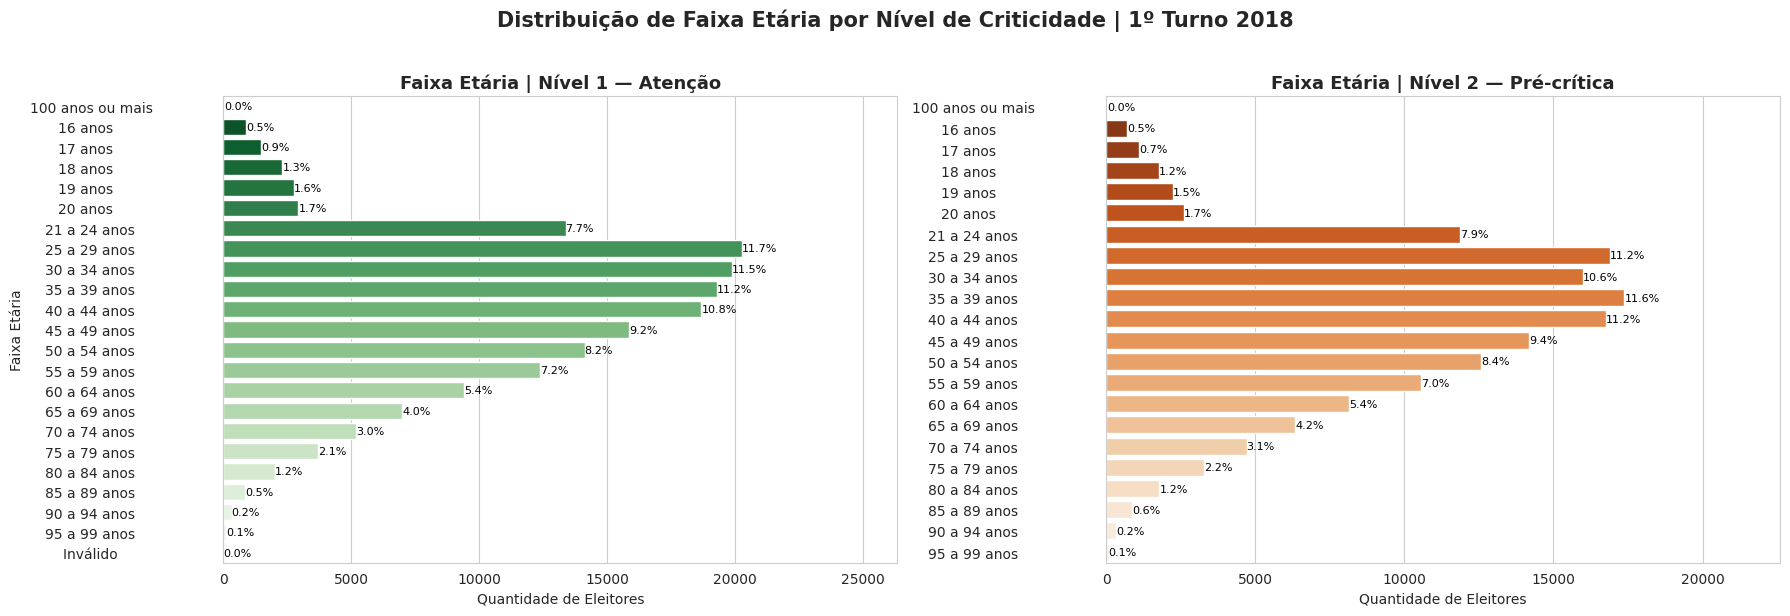

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Nível 1
df_idade_n1 = df_perfil_n1.groupby('DS_FAIXA_ETARIA')['QT_ELEITORES_PERFIL'].sum()
print(df_idade_n1)
sns.barplot(x=df_idade_n1.values, y=df_idade_n1.index, palette='Greens_r', ax=ax1)
total_n1 = df_idade_n1.sum()
for index, value in enumerate(df_idade_n1.values):
    pct = (value / total_n1 * 100).round(1)
    ax1.text(value + 0.5, index, f'{pct}%', color='black', va='center', fontsize=8)
ax1.set_title('Faixa Etária | Nível 1 — Atenção', fontsize=13, fontweight='bold')
ax1.set_xlabel('Quantidade de Eleitores')
ax1.set_ylabel('Faixa Etária')
ax1.set_xlim(0, df_idade_n1.max() * 1.3)

# Nível 2
df_idade_n2 = df_perfil_n2.groupby('DS_FAIXA_ETARIA')['QT_ELEITORES_PERFIL'].sum()
print(df_idade_n2)
sns.barplot(x=df_idade_n2.values, y=df_idade_n2.index, palette='Oranges_r', ax=ax2)
total_n2 = df_idade_n2.sum()
for index, value in enumerate(df_idade_n2.values):
    pct = (value / total_n2 * 100).round(1)
    ax2.text(value + 0.5, index, f'{pct}%', color='black', va='center', fontsize=8)
ax2.set_title('Faixa Etária | Nível 2 — Pré-crítica', fontsize=13, fontweight='bold')
ax2.set_xlabel('Quantidade de Eleitores')
ax2.set_ylabel('')
ax2.set_xlim(0, df_idade_n2.max() * 1.3)

plt.suptitle('Distribuição de Faixa Etária por Nível de Criticidade | 1º Turno 2018', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

DS_GRAU_ESCOLARIDADE
ANALFABETO                       10898
ENSINO FUNDAMENTAL COMPLETO       7928
ENSINO FUNDAMENTAL INCOMPLETO    55403
ENSINO MÉDIO COMPLETO            34859
ENSINO MÉDIO INCOMPLETO          30004
LÊ E ESCREVE                     19373
SUPERIOR COMPLETO                 7660
SUPERIOR INCOMPLETO               6668
Name: QT_ELEITORES_PERFIL, dtype: int64
DS_GRAU_ESCOLARIDADE
ANALFABETO                       10770
ENSINO FUNDAMENTAL COMPLETO       6514
ENSINO FUNDAMENTAL INCOMPLETO    52202
ENSINO MÉDIO COMPLETO            26922
ENSINO MÉDIO INCOMPLETO          24949
LÊ E ESCREVE                     19076
SUPERIOR COMPLETO                 5361
SUPERIOR INCOMPLETO               4485
Name: QT_ELEITORES_PERFIL, dtype: int64


/tmp/ipykernel_5811/1480282527.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_esc_n1.values, y=df_esc_n1.index, palette='Greens_r', ax=ax1)
/tmp/ipykernel_5811/1480282527.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_esc_n2.values, y=df_esc_n2.index, palette='Oranges_r', ax=ax2)


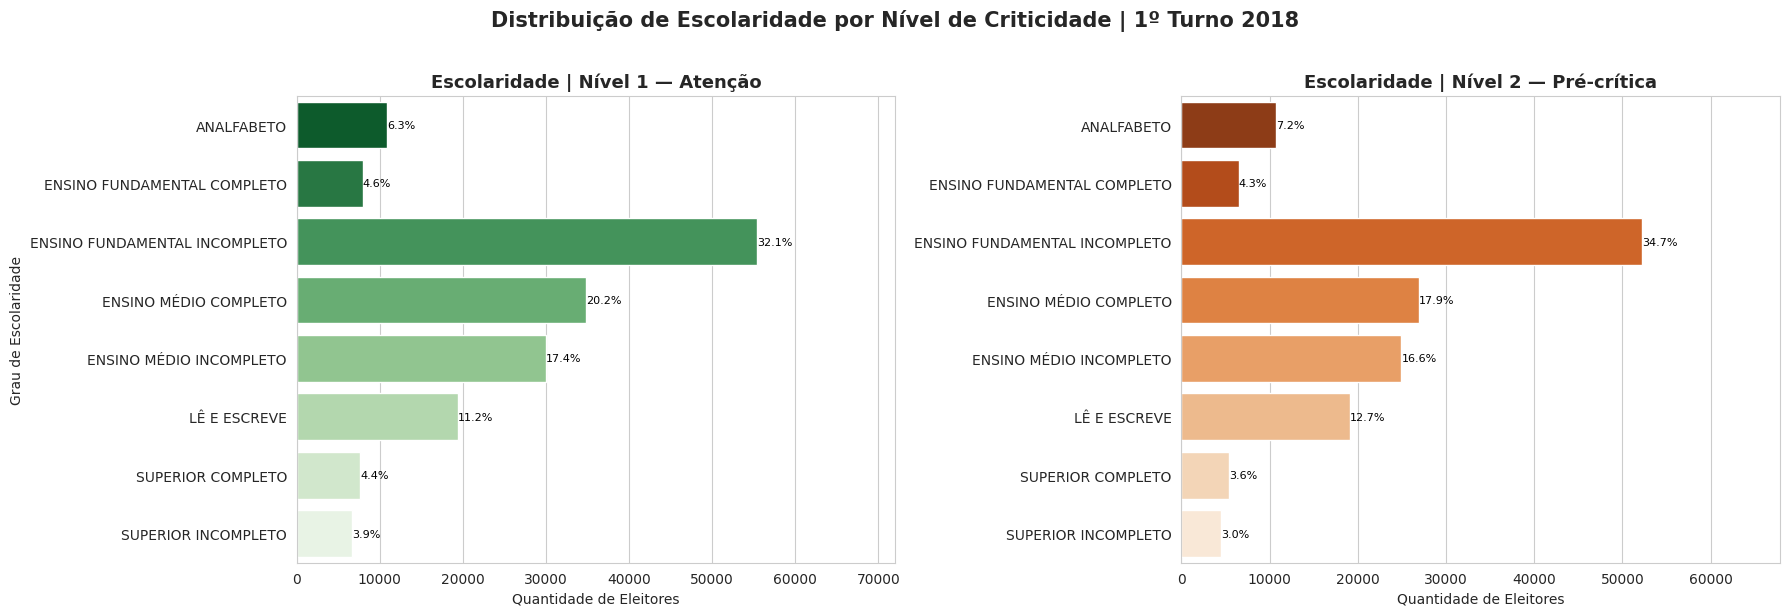

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Nível 1
df_esc_n1 = df_perfil_n1.groupby('DS_GRAU_ESCOLARIDADE')['QT_ELEITORES_PERFIL'].sum()
print(df_esc_n1)
sns.barplot(x=df_esc_n1.values, y=df_esc_n1.index, palette='Greens_r', ax=ax1)
total_n1 = df_esc_n1.sum()
for index, value in enumerate(df_esc_n1.values):
    pct = (value / total_n1 * 100).round(1)
    ax1.text(value + 0.5, index, f'{pct}%', color='black', va='center', fontsize=8)
ax1.set_title('Escolaridade | Nível 1 — Atenção', fontsize=13, fontweight='bold')
ax1.set_xlabel('Quantidade de Eleitores')
ax1.set_ylabel('Grau de Escolaridade')
ax1.set_xlim(0, df_esc_n1.max() * 1.3)

# Nível 2
df_esc_n2 = df_perfil_n2.groupby('DS_GRAU_ESCOLARIDADE')['QT_ELEITORES_PERFIL'].sum()
print(df_esc_n2)
sns.barplot(x=df_esc_n2.values, y=df_esc_n2.index, palette='Oranges_r', ax=ax2)
total_n2 = df_esc_n2.sum()
for index, value in enumerate(df_esc_n2.values):
    pct = (value / total_n2 * 100).round(1)
    ax2.text(value + 0.5, index, f'{pct}%', color='black', va='center', fontsize=8)
ax2.set_title('Escolaridade | Nível 2 — Pré-crítica', fontsize=13, fontweight='bold')
ax2.set_xlabel('Quantidade de Eleitores')
ax2.set_ylabel('')
ax2.set_xlim(0, df_esc_n2.max() * 1.3)

plt.suptitle('Distribuição de Escolaridade por Nível de Criticidade | 1º Turno 2018', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [32]:
# PCD
total_pcd_n1 = df_perfil_n1['QT_ELEITORES_DEFICIENCIA'].sum()
total_pcd_n2 = df_perfil_n2['QT_ELEITORES_DEFICIENCIA'].sum()
total_el_n1 = df_perfil_n1['QT_ELEITORES_PERFIL'].sum()
total_el_n2 = df_perfil_n2['QT_ELEITORES_PERFIL'].sum()


print(f"Nível 1 — Total PCD: {total_pcd_n1}")
print(f"           Representa: {(total_pcd_n1/total_el_n1*100):.2f}%")
print(f"Nível 2 — Total PCD: {total_pcd_n2}")
print(f"           Representa: {(total_pcd_n2/total_el_n2*100):.2f}%")

# Biometria
total_bio_n1 = df_perfil_n1['QT_ELEITORES_BIOMETRIA'].sum()
total_bio_n2 = df_perfil_n2['QT_ELEITORES_BIOMETRIA'].sum()

print(f"Nível 1 — Total com biometria: {total_bio_n1}")
print(f"           Representa: {(total_bio_n1/total_el_n1*100):.2f}%")
print(f"Nível 2 — Total com biometria: {total_bio_n2}")
print(f"           Representa: {(total_bio_n2/total_el_n2*100):.2f}%")

Nível 1 — Total PCD: 849
           Representa: 0.49%
Nível 2 — Total PCD: 652
           Representa: 0.43%
Nível 1 — Total com biometria: 163934
           Representa: 94.87%
Nível 2 — Total com biometria: 143746
           Representa: 95.65%


In [33]:
chaves_urna = ['NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO', 'TURNO']

colunas_maquina = [
    'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO', 'TURNO', 'CONTINGENCIA', 
    'QT_ELEITORES_ANTES_17', 'DELTA_T_ANTES_17', 'DESVIO_ANTES_17', 
    'QT_ELEITORES_DEPOIS_17', 'DELTA_T_DEPOIS_17', 'DESVIO_DEPOIS_17', 
    'ULTIMO_VOTO', 'TIMEOUT_BIOMETRIA', 'TECLA_INDEVIDA', 'INATIVIDADE', 
    'SEM_BIOMETRIA', 'TITULO_INVALIDO', 'ATRASO_FILA_MINUTOS', 'STATUS'
]

df_urnas_unicas = criticas_2022[colunas_maquina].drop_duplicates(subset=chaves_urna)

df_escolaridade = criticas_2022.pivot_table(
    index=chaves_urna,
    columns='DS_GRAU_ESCOLARIDADE',
    values='QT_ELEITORES_PERFIL',
    aggfunc='sum',
    fill_value=0
).reset_index()

df_escolaridade.columns = chaves_urna + [f'ESC_{col}' for col in df_escolaridade.columns[len(chaves_urna):]]


df_idade = criticas_2022.pivot_table(
    index=chaves_urna,
    columns='DS_FAIXA_ETARIA',
    values='QT_ELEITORES_PERFIL',
    aggfunc='sum',
    fill_value=0
).reset_index()

df_idade.columns = chaves_urna + [f'IDADE_{col}' for col in df_idade.columns[len(chaves_urna):]]

df_genero = criticas_2022.pivot_table(
    index=chaves_urna,
    columns='DS_GENERO',
    values='QT_ELEITORES_PERFIL',
    aggfunc='sum',
    fill_value=0
).reset_index()

df_genero.columns = chaves_urna + [f'GENERO_{col}' for col in df_genero.columns[len(chaves_urna):]]

df_pcd = criticas_2022.groupby(chaves_urna)['QT_ELEITORES_DEFICIENCIA'].sum().reset_index()
df_pcd.rename(columns={'QT_ELEITORES_DEFICIENCIA': 'QTD_PCD'}, inplace=True)

df_bio = criticas_2022.groupby(chaves_urna)['QT_ELEITORES_BIOMETRIA'].sum().reset_index()
df_bio.rename(columns={'QT_ELEITORES_BIOMETRIA': 'QTD_PERFIL_BIOMETRIA'}, inplace=True)

df_final = df_urnas_unicas.copy()

df_final = pd.merge(df_final, df_escolaridade, on=chaves_urna, how='left')
df_final = pd.merge(df_final, df_idade, on=chaves_urna, how='left')
df_final = pd.merge(df_final, df_genero, on=chaves_urna, how='left')
df_final = pd.merge(df_final, df_pcd, on=chaves_urna, how='left')
df_final = pd.merge(df_final, df_bio, on=chaves_urna, how='left')

colunas_novas = [col for col in df_final.columns if col not in colunas_maquina]
df_final[colunas_novas] = df_final[colunas_novas].fillna(0).astype(int)

print(f"Dimensões do arquivo final: {len(df_final)} urnas e {len(df_final.columns)} colunas.")
display(df_final.head())

df_final.to_csv("urnas_perfil.csv", index=False, sep=";", encoding="utf-8-sig")

Dimensões do arquivo final: 1663 urnas e 54 colunas.


,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO,CONTINGENCIA,QT_ELEITORES_ANTES_17,DELTA_T_ANTES_17,DESVIO_ANTES_17,QT_ELEITORES_DEPOIS_17,DELTA_T_DEPOIS_17,...,IDADE_75 a 79 anos,IDADE_80 a 84 anos,IDADE_85 a 89 anos,IDADE_90 a 94 anos,IDADE_95 a 99 anos,IDADE_Inválido,GENERO_FEMININO,GENERO_MASCULINO,QTD_PCD,QTD_PERFIL_BIOMETRIA
0,FREI PAULO,24,117,1º Turno,Não,283,61.47,32.90,48,51.21,...,7,5,2,1,1,0,218,167,2,359
1,JAPARATUBA,11,90,1º Turno,Não,248,84.64,59.58,28,54.50,...,21,3,2,0,0,0,149,120,1,268
2,SÃO CRISTÓVÃO,21,116,1º Turno,Não,281,65.05,40.47,2,237.00,...,10,2,3,0,0,0,164,181,4,302
3,PIRAMBU,11,51,1º Turno,Não,216,74.31,67.83,46,54.63,...,12,3,4,2,1,0,143,150,0,282
4,SÃO CRISTÓVÃO,21,159,1º Turno,Não,306,61.19,34.33,3,52.00,...,5,1,1,0,1,0,186,178,4,364


In [34]:
df_urnas_unicas = df_perfil_n2[colunas_maquina].drop_duplicates(subset=chaves_urna)

df_escolaridade = df_perfil_n2.pivot_table(
    index=chaves_urna,
    columns='DS_GRAU_ESCOLARIDADE',
    values='QT_ELEITORES_PERFIL',
    aggfunc='sum',
    fill_value=0
).reset_index()

df_escolaridade.columns = chaves_urna + [f'ESC_{col}' for col in df_escolaridade.columns[len(chaves_urna):]]


df_idade = df_perfil_n2.pivot_table(
    index=chaves_urna,
    columns='DS_FAIXA_ETARIA',
    values='QT_ELEITORES_PERFIL',
    aggfunc='sum',
    fill_value=0
).reset_index()

df_idade.columns = chaves_urna + [f'IDADE_{col}' for col in df_idade.columns[len(chaves_urna):]]

df_genero = df_perfil_n2.pivot_table(
    index=chaves_urna,
    columns='DS_GENERO',
    values='QT_ELEITORES_PERFIL',
    aggfunc='sum',
    fill_value=0
).reset_index()

df_genero.columns = chaves_urna + [f'GENERO_{col}' for col in df_genero.columns[len(chaves_urna):]]

df_pcd = df_perfil_n2.groupby(chaves_urna)['QT_ELEITORES_DEFICIENCIA'].sum().reset_index()
df_pcd.rename(columns={'QT_ELEITORES_DEFICIENCIA': 'QTD_PCD'}, inplace=True)

df_bio = df_perfil_n2.groupby(chaves_urna)['QT_ELEITORES_BIOMETRIA'].sum().reset_index()
df_bio.rename(columns={'QT_ELEITORES_BIOMETRIA': 'QTD_PERFIL_BIOMETRIA'}, inplace=True)

df_final = df_urnas_unicas.copy()

df_final = pd.merge(df_final, df_escolaridade, on=chaves_urna, how='left')
df_final = pd.merge(df_final, df_idade, on=chaves_urna, how='left')
df_final = pd.merge(df_final, df_genero, on=chaves_urna, how='left')
df_final = pd.merge(df_final, df_pcd, on=chaves_urna, how='left')
df_final = pd.merge(df_final, df_bio, on=chaves_urna, how='left')

colunas_novas = [col for col in df_final.columns if col not in colunas_maquina]
df_final[colunas_novas] = df_final[colunas_novas].fillna(0).astype(int)

print(f"Dimensões do arquivo final: {len(df_final)} urnas e {len(df_final.columns)} colunas.")
display(df_final.head())

df_final.to_csv("urnas_perfil_nivel2.csv", index=False, sep=";", encoding="utf-8-sig")

Dimensões do arquivo final: 453 urnas e 53 colunas.


,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO,CONTINGENCIA,QT_ELEITORES_ANTES_17,DELTA_T_ANTES_17,DESVIO_ANTES_17,QT_ELEITORES_DEPOIS_17,DELTA_T_DEPOIS_17,...,IDADE_70 a 74 anos,IDADE_75 a 79 anos,IDADE_80 a 84 anos,IDADE_85 a 89 anos,IDADE_90 a 94 anos,IDADE_95 a 99 anos,GENERO_FEMININO,GENERO_MASCULINO,QTD_PCD,QTD_PERFIL_BIOMETRIA
0,JAPARATUBA,11,90,1º Turno,Não,248,84.64,59.58,28,54.50,...,18,21,3,2,0,0,149,120,1,268
1,NOSSA SENHORA DO SOCORRO,34,97,1º Turno,Não,280,59.66,40.72,20,58.35,...,6,2,2,0,0,0,195,165,2,358
2,ARACAJU,27,246,1º Turno,Não,326,59.94,42.53,24,48.71,...,8,9,3,3,0,0,224,187,3,409
3,JAPARATUBA,11,16,1º Turno,Não,239,72.21,65.22,19,72.47,...,9,6,4,1,3,0,147,159,0,289
4,NOSSA SENHORA DA GLÓRIA,17,108,1º Turno,Não,252,74.48,46.66,22,61.09,...,15,13,8,5,2,0,202,148,0,350


In [35]:
df_urnas_unicas = df_perfil_n1[colunas_maquina].drop_duplicates(subset=chaves_urna)

df_escolaridade = df_perfil_n1.pivot_table(
    index=chaves_urna,
    columns='DS_GRAU_ESCOLARIDADE',
    values='QT_ELEITORES_PERFIL',
    aggfunc='sum',
    fill_value=0
).reset_index()

df_escolaridade.columns = chaves_urna + [f'ESC_{col}' for col in df_escolaridade.columns[len(chaves_urna):]]


df_idade = df_perfil_n1.pivot_table(
    index=chaves_urna,
    columns='DS_FAIXA_ETARIA',
    values='QT_ELEITORES_PERFIL',
    aggfunc='sum',
    fill_value=0
).reset_index()

df_idade.columns = chaves_urna + [f'IDADE_{col}' for col in df_idade.columns[len(chaves_urna):]]

df_genero = df_perfil_n1.pivot_table(
    index=chaves_urna,
    columns='DS_GENERO',
    values='QT_ELEITORES_PERFIL',
    aggfunc='sum',
    fill_value=0
).reset_index()

df_genero.columns = chaves_urna + [f'GENERO_{col}' for col in df_genero.columns[len(chaves_urna):]]

df_pcd = df_perfil_n1.groupby(chaves_urna)['QT_ELEITORES_DEFICIENCIA'].sum().reset_index()
df_pcd.rename(columns={'QT_ELEITORES_DEFICIENCIA': 'QTD_PCD'}, inplace=True)

df_bio = df_perfil_n1.groupby(chaves_urna)['QT_ELEITORES_BIOMETRIA'].sum().reset_index()
df_bio.rename(columns={'QT_ELEITORES_BIOMETRIA': 'QTD_PERFIL_BIOMETRIA'}, inplace=True)

df_final = df_urnas_unicas.copy()

df_final = pd.merge(df_final, df_escolaridade, on=chaves_urna, how='left')
df_final = pd.merge(df_final, df_idade, on=chaves_urna, how='left')
df_final = pd.merge(df_final, df_genero, on=chaves_urna, how='left')
df_final = pd.merge(df_final, df_pcd, on=chaves_urna, how='left')
df_final = pd.merge(df_final, df_bio, on=chaves_urna, how='left')

colunas_novas = [col for col in df_final.columns if col not in colunas_maquina]
df_final[colunas_novas] = df_final[colunas_novas].fillna(0).astype(int)

print(f"Dimensões do arquivo final: {len(df_final)} urnas e {len(df_final.columns)} colunas.")
display(df_final.head())

df_final.to_csv("urnas_perfil_nivel1.csv", index=False, sep=";", encoding="utf-8-sig")

Dimensões do arquivo final: 532 urnas e 54 colunas.


,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO,CONTINGENCIA,QT_ELEITORES_ANTES_17,DELTA_T_ANTES_17,DESVIO_ANTES_17,QT_ELEITORES_DEPOIS_17,DELTA_T_DEPOIS_17,...,IDADE_75 a 79 anos,IDADE_80 a 84 anos,IDADE_85 a 89 anos,IDADE_90 a 94 anos,IDADE_95 a 99 anos,IDADE_Inválido,GENERO_FEMININO,GENERO_MASCULINO,QTD_PCD,QTD_PERFIL_BIOMETRIA
0,SÃO CRISTÓVÃO,21,116,1º Turno,Não,281,65.05,40.47,2,237.00,...,10,2,3,0,0,0,164,181,4,302
1,SANTA LUZIA DO ITANHY,35,37,1º Turno,Não,210,80.32,44.94,4,74.75,...,12,4,2,0,0,0,161,111,0,272
2,AQUIDABÃ,3,29,1º Turno,Não,202,74.01,60.83,2,100.00,...,7,2,1,0,1,0,125,119,1,231
3,TOBIAS BARRETO,23,75,1º Turno,Não,229,87.39,58.53,6,75.67,...,19,7,2,1,1,0,134,152,2,262
4,ITABAIANA,9,118,1º Turno,Não,244,61.62,38.90,9,70.89,...,9,3,1,0,0,0,169,130,1,277
